In [1]:
using ModelingToolkit, OrdinaryDiffEq, Plots
using ModelingToolkit: t, D

In [2]:
@mtkmodel subsystem begin
    @parameters begin
        k = 5.0
    end
    @variables begin
        x(t) = 0.0
        y(t) = 0.0
    end
    @equations begin
        x ~ k * D(x)
        D(y) ~ -k
    end
    @continuous_events begin
        [x ~ 1.5] => [x ~ 5, y ~ 5]
        [t ~ 4] => [x ~ 10]
    end
end

@mtkmodel M begin
    @components begin
        s = subsystem()
    end
end;

In [3]:
@mtkbuild sys = M()
prob = ODEProblem(sys, [], (0, 20.0))
sol = solve(prob);

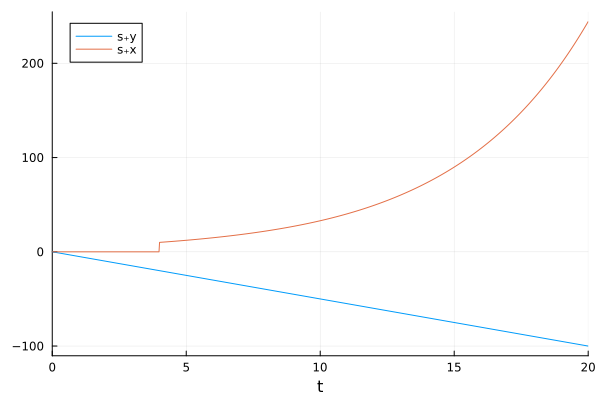

In [4]:
plot(sol)